In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
# Maxwell-Boltzmann function for fitting histograms
def MB(v:np.array, temp:float,C:float):
    return C*(1/( (2*np.pi*temp)**(1.5)) )*4*np.pi*(v**2)*np.exp(-(v**2)/(2*temp))

# Exercise 04.1: Maxwell-Boltzmann distribution


The Maxwell-Boltzmann distribution using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$


## Implementation

### Measure of POFV

Set Maximum velocity at $4\sqrt{T^*}$ so that the histogram will consider the 99.8866% of the Maxwell-Boltzmann distribution. Then create a vector of `_n_bins` of width `_bin_size_v=4*sqrt(_temp)/_npart`. 

For every particle compute the norm of velocity and increment the corresponding bin at position `k=floor(norm(_particle(i).get_velocity())/_bin_size_v)`


```c++

vec vel_hist(_n_bins_v);
vel_hist.zeros();
    [....]
for(int i=0; i<_npart; i++)
{
  // bin k = [k*_bin_size_v, (k+1)*_bin_size_v]      
  int k=floor(norm(_particle(i).getvelocity())/_bin_size_v);
  //ignore velocities greater than the maximum
  if(k<_n_bins_v) vel_hist(k)+=1;
}

//save measure on consecutives indexes 
for (int k=0; k<_n_bins_v; ++k)
{
    _measurement(_index_pofv+k)=vel_hist(k);
}

```

### Average of POFV
```c++
coutf.open("../OUTPUT/pofv.dat", ios::app);

for(int k=0; k<_n_bins_v; ++k)
{
    average=_average(_index_pofv+k);
    sum_average = _global_av(_index_pofv+k);
    sum_ave2 = _global_av2(_index_pofv+k);

    coutf<<setw(12)<<k*_bin_size_v+_bin_size_v/2.
         <<setw(12)<<average/_npart  
         <<setw(12)<<sum_average/(blk*_npart)
         <<setw(12)<<this->error(sum_average/_npart, sum_ave2/(_npart*_npart), blk)
         <<endl;

```

## Data visualization
### Load data
Below are reported the measure of the velocity distribution for a MD simulation computed with the conditions:
- TEMPERATURE= 2
- NPART= 108
- SIDE=      12.9266     12.9266     12.9266
- R_CUT= 5
- DELTA= 0.001
- NBLOCKS= 200
- NSTEPS= 2000


In [5]:
# POFV data
df_mb=pd.read_csv('OUTPUT/distrib/MB/pofv.dat', header=None, names=['#vel', 'block_avg', 'prog_av', 'err'], skiprows=1,
               sep=r"\s+")
df_mb['block']=0
df_mb['block']=df_mb.index//30

# Temperature data
T=pd.read_csv('OUTPUT/distrib/MB/temperature.dat', skiprows=1, delimiter=r'\s+',names=['block','actual_T','T_ave','error'])



### Fit temperature from POFV

In [17]:
mb_fit={'T_block':[], 'T_ave':[], 'C_block':[], 'C_ave':[]}

for k in df_mb.block.unique():
    # block avg
    temp_ba, c_ba = curve_fit(MB, df_mb.loc[df_mb.block==k]['#vel'], df_mb.loc[df_mb.block==k]['block_avg'] )[0] 
    mb_fit['T_block'].append(temp_ba)
    mb_fit['C_block'].append(c_ba)
    # progressive avg
    temp_pa, c_pa = curve_fit(MB, df_mb.loc[df_mb.block==k]['#vel'], df_mb.loc[df_mb.block==k]['prog_av'] )[0] 
    mb_fit['T_ave'].append(temp_pa)
    mb_fit['C_ave'].append(c_pa)


mb_fit=pd.DataFrame(mb_fit)

### Plot distribution at different blocks
In the graph below are shown both the block averages (on the left) and the progressive averages (on the right) of the velocity distribution for some block values.

The progressive averages converge to an actual Maxwell Boltzmann distribution.



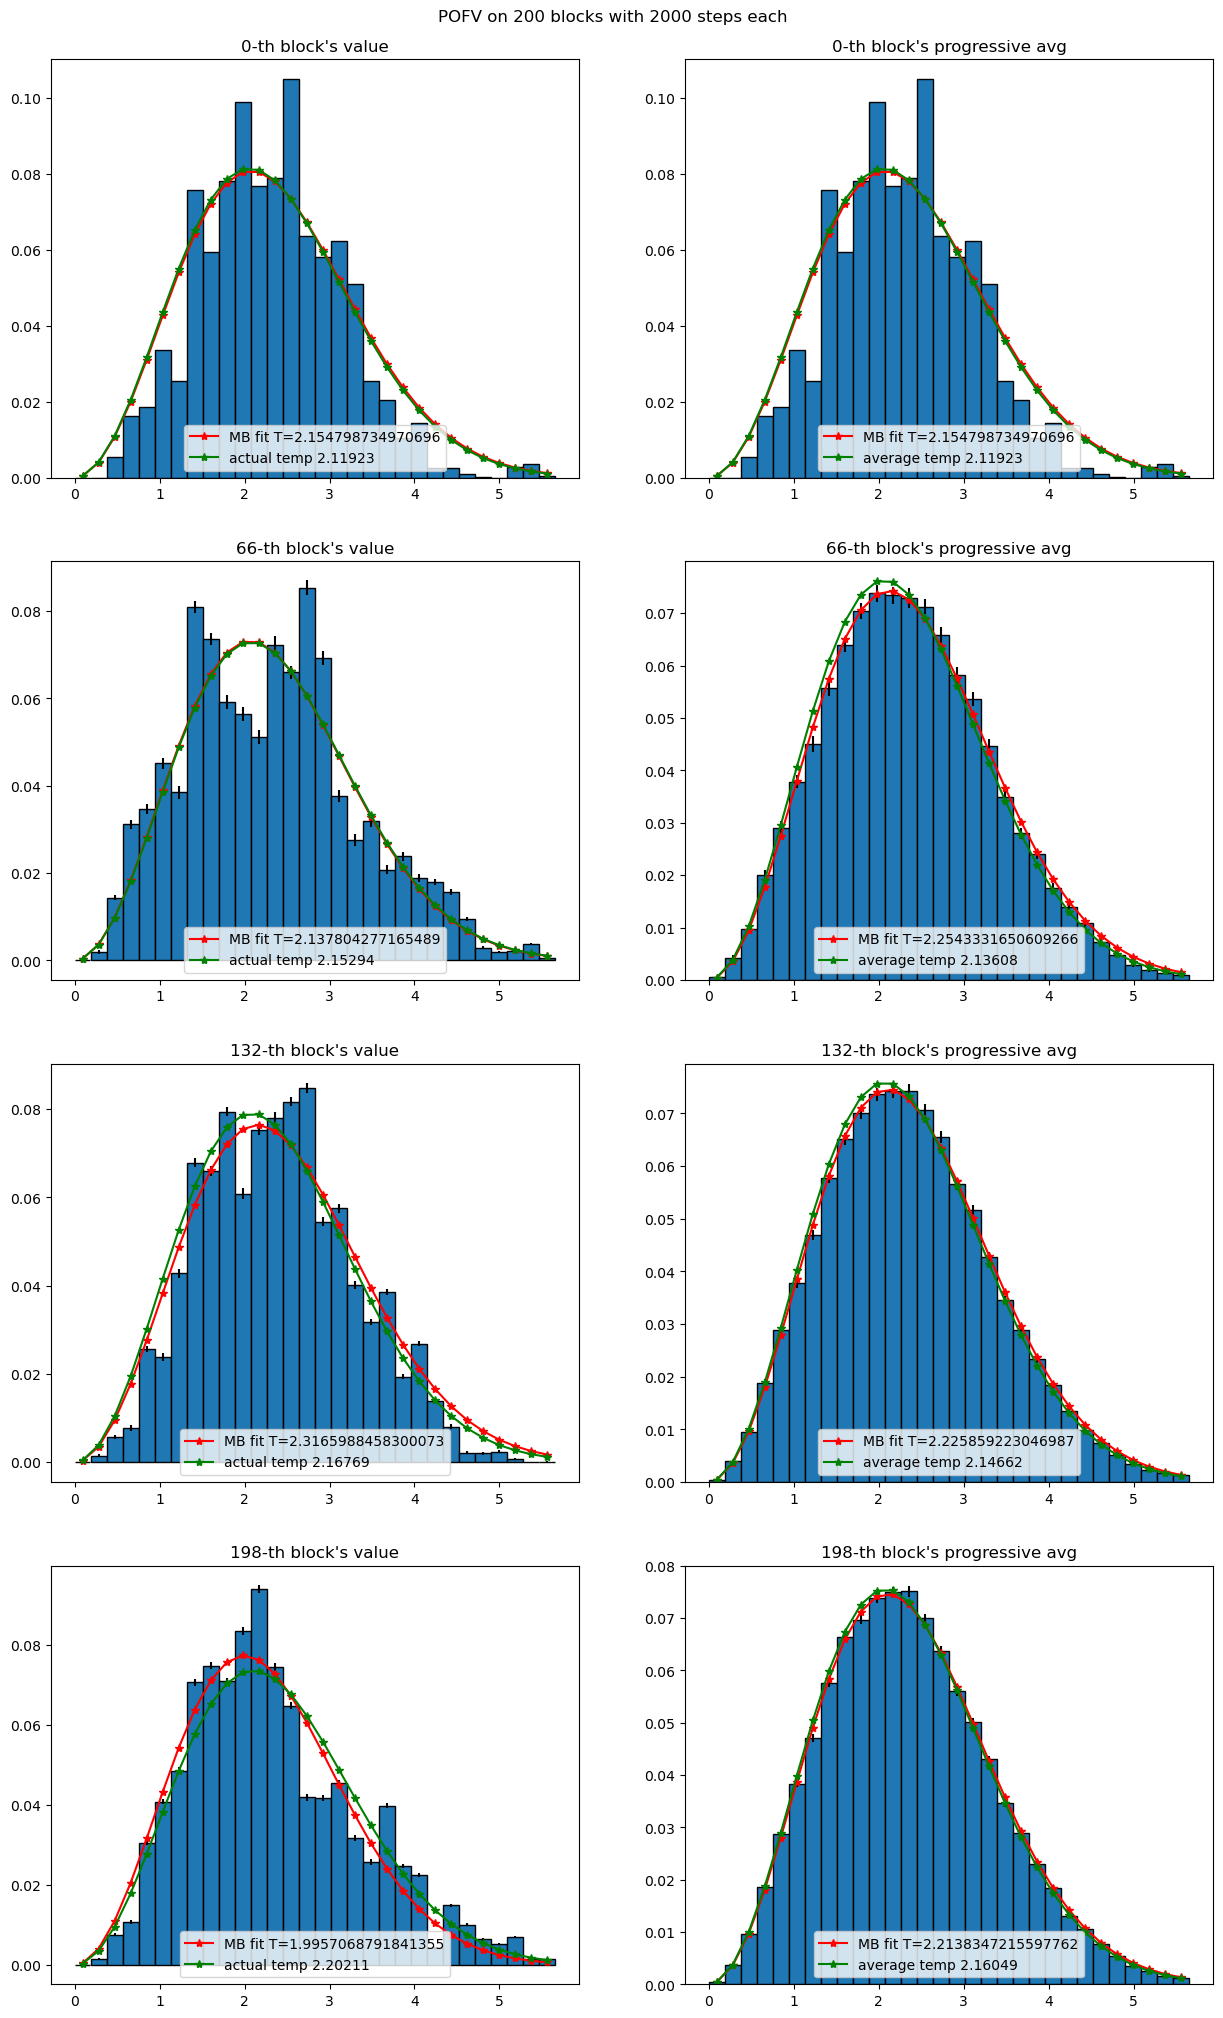

In [58]:
fig, ax=plt.subplots(nrows=4, ncols=2)
fig.set_figwidth(15)
fig.set_figheight(25)

fig.suptitle('POFV on 200 blocks with 2000 steps each', y=0.9)

step=df_mb.block.max()//3
for k in range(4):
    #select k block pofv data 
    dfb=df_mb.loc[df_mb['block']==step*k].reset_index(drop=True)

    ax[k,  0].set_title(f'{step*k}-th block\'s value')
    
    # actual data
    ax[k,  0].bar(
        dfb['#vel'], dfb['block_avg'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    
    # fit 
    ax[k, 0].plot(
        dfb['#vel'], MB(dfb['#vel'], mb_fit['T_block'][step*k] ,mb_fit['C_block'][step*k])
        , marker='*', c='r', label=f'MB fit T={mb_fit['T_block'][step*k]}')
    
    ax[k, 0].plot(
        dfb['#vel'], MB(dfb['#vel'], T.actual_T[k], mb_fit['C_block'][step*k])
        , marker='*', c='g', label=f'actual temp {T.actual_T[k]}')
    
    ax[k, 0].legend(loc='lower center')

    # prog avg
    ax[k,  1].set_title(f'{step*k}-th block\'s progressive avg')
    # actual data
    ax[k,  1].bar(
        dfb['#vel'], dfb['prog_av'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    # fit 
    ax[k, 1].plot(
        dfb['#vel'], MB(dfb['#vel'], mb_fit['T_ave'][step*k],mb_fit['C_ave'][step*k])
        , marker='*', c='r', label=f'MB fit T={mb_fit['T_ave'][step*k]}')
    ax[k, 1].plot(
        dfb['#vel'], MB(dfb['#vel'], T.T_ave[k], mb_fit['C_ave'][step*k])
        , marker='*', c='g', label=f'average temp {T.T_ave[k]}')
    
    ax[k, 1].legend(loc='lower center')
plt.show()

In the following image are plotted the values obtained from the fit for the actual and progressive averages of $p(v)$ compared to the measured values of the simulation

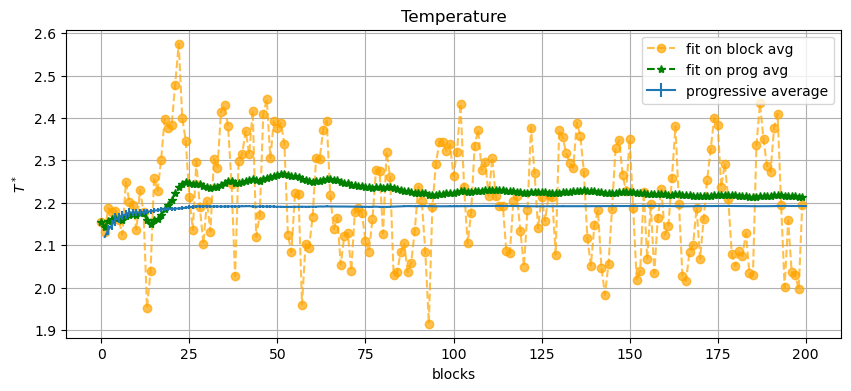

In [60]:
plt.figure(figsize=(10, 4))
plt.title('Temperature')
plt.plot(mb_fit['T_block'],'--o',color='orange', alpha=0.7,  label='fit on block avg')
plt.plot(mb_fit['T_ave'],'--*', color='g', label='fit on prog avg')
plt.errorbar(T.block, T['T_ave'], yerr=T.error,  label='progressive average')
plt.xlabel('blocks')
plt.ylabel(r'$T^*$')
plt.grid()
plt.legend()
plt.show()

### Properties 
Below are reported the measures obtained starting from a Maxwell-Boltzmann distribution

In [3]:
K=pd.read_csv('OUTPUT/distrib/MB/kinetic_energy.dat', delimiter=r"\s+")
U=pd.read_csv('OUTPUT/distrib/MB/potential_energy.dat', delimiter=r"\s+")
P=pd.read_csv('OUTPUT/distrib/MB/pressure.dat', delimiter=r"\s+")

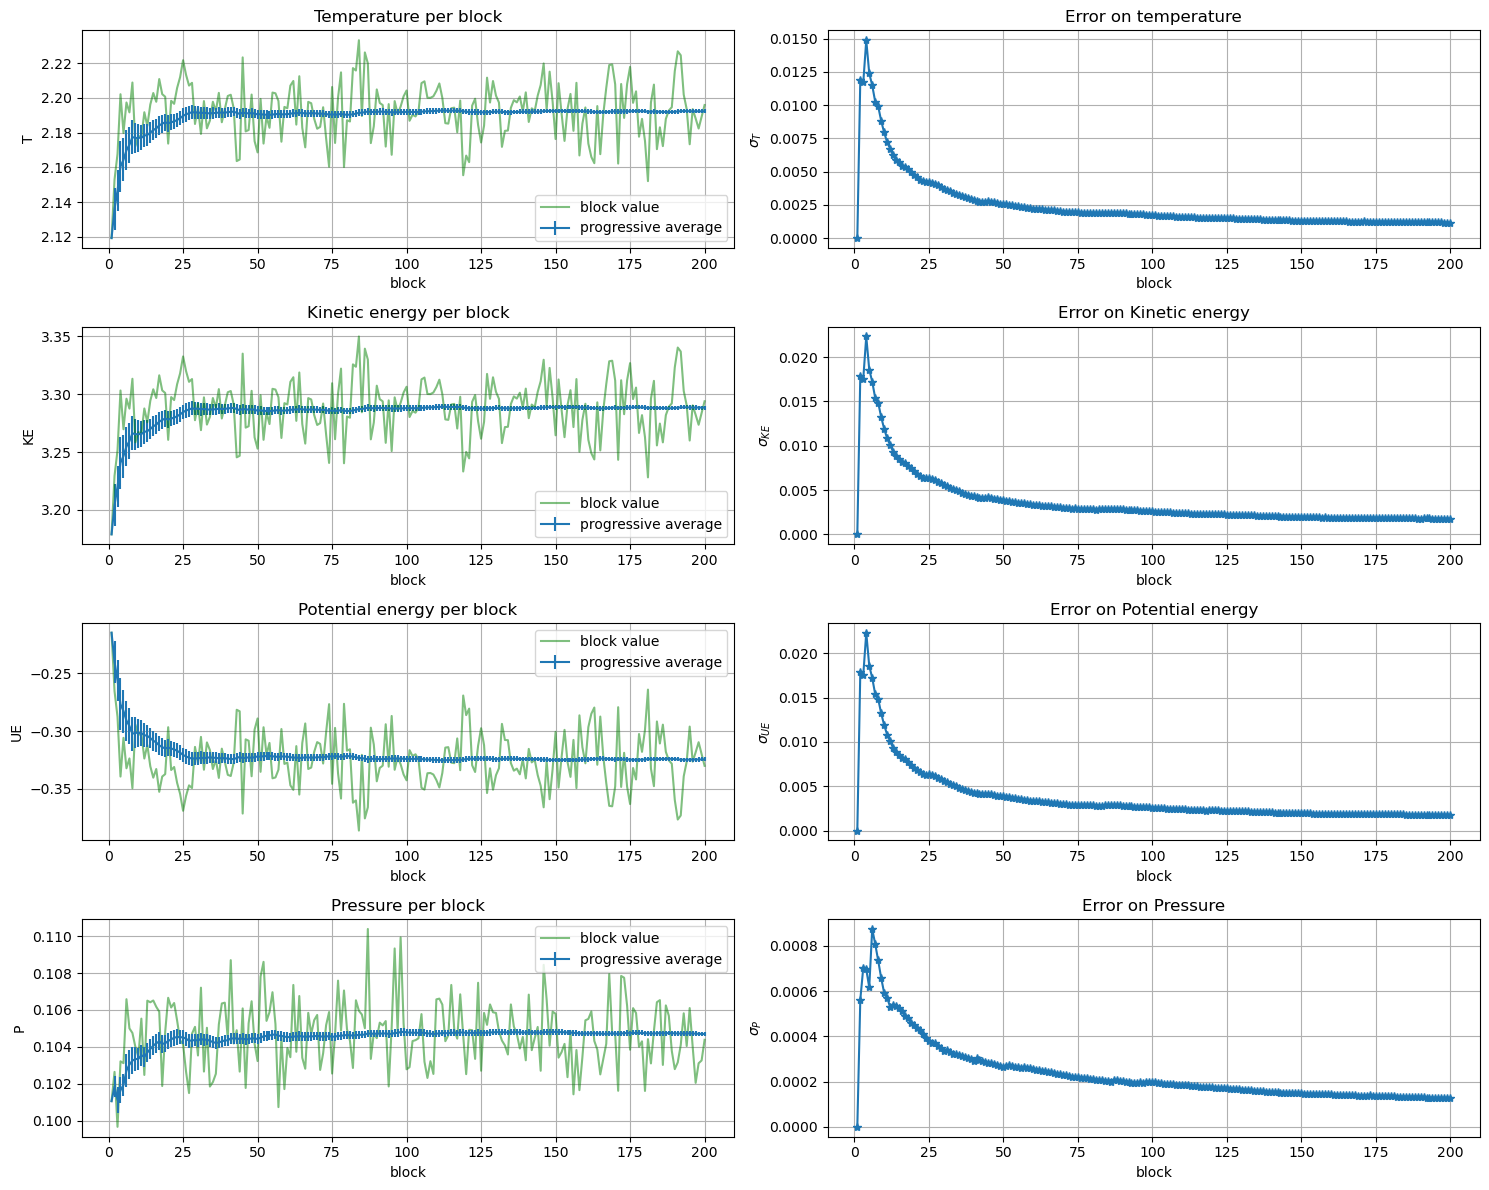

In [6]:
fig, ax = plt.subplots(4,2,  figsize=(15, 12))

ax[0, 0].set_title('Temperature per block')
# block averages
ax[0, 0].plot(T.block, T.actual_T, '-',color='g', alpha=0.5,  label='block value')
# progressive averages
ax[0, 0].errorbar(T.block, T['T_ave'], yerr=T.error,  label='progressive average')
ax[0, 0].set_ylabel('T')

ax[0,1].set_title('Error on temperature')
ax[0,1].plot(T.block, T.error, '-*')
ax[0,1].set_ylabel(r'$\sigma_T$')


ax[1,0].set_title('Kinetic energy per block')
# progressive averages
ax[1,0].errorbar(K['#BLOCK:'], K['KE_AVE:'], yerr=K['ERROR:'], label='progressive average')
# block averages
ax[1,0].plot(K['#BLOCK:'], K['ACTUAL_KE:'], '-',color='g', alpha=0.5,  label='block value')
ax[1,0].set_ylabel('KE')


ax[1,1].set_title('Error on Kinetic energy')
ax[1,1].plot(K['#BLOCK:'], K['ERROR:'], '-*')
ax[1,1].set_ylabel(r'$\sigma_{KE}$')


ax[2,0].set_title('Potential energy per block')
ax[2,0].plot(U['#BLOCK:'], U['ACTUAL_PE:'], ls='-', color='g', alpha=0.5,  label='block value')
ax[2,0].errorbar(U['#BLOCK:'], U['PE_AVE:'], yerr=U['ERROR:'], label='progressive average')
ax[2,0].set_ylabel('UE')

ax[2,1].set_title('Error on Potential energy')
ax[2,1].plot(U['#BLOCK:'], U['ERROR:'], '-*')
ax[2,1].set_ylabel(r'$\sigma_{UE}$')


ax[3,0].set_title('Pressure per block')
ax[3,0].plot(P['#BLOCK:'], P['ACTUAL_P:'], ls='-', color='g', alpha=0.5,  label='block value')
ax[3,0].errorbar(P['#BLOCK:'], P['P_AVE:'], yerr=P['ERROR:'], label='progressive average')
ax[3,0].set_ylabel('P')

ax[3,1].set_title('Error on Pressure')
ax[3,1].plot(P['#BLOCK:'], P['ERROR:'], '-*')
ax[3,1].set_ylabel(r'$\sigma_{P}$')

for k in range(4):
    for j in range(2):
        ax[k,j].grid()
        ax[k, j].set_xlabel('block')
    ax[k, 0].legend()

fig.tight_layout()

plt.show()

### Histograms Heatmap 

In [ ]:
histos=pd.DataFrame(columns=['vel']+[f'block_{k}' for k in range(df_mb['block'].max())])
histos['vel']=df_mb.loc[df_mb['block']==0]['#vel'].values
for k in range(df_mb['block'].max()):
    histos[f'block_{k}']=df_mb.loc[df_mb.block==k]['block_avg'].values 

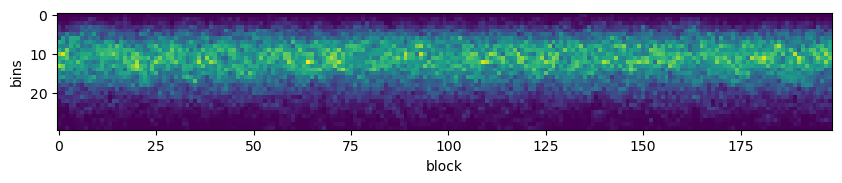

In [122]:
fig,ax = plt.subplots(figsize=(10,10))

ax.imshow(histos[[f'block_{k}' for k in range(len(histos.columns)-1)]])
plt.xlabel('block')
plt.ylabel('bins')
plt.savefig('images/MB_hist.png')
plt.show()

# Exercise 04.2

##  Delta distribution implementation


```C++
//initial velocity
double velt=sqrt(3*_temp);
for (int i=0; i<_npart; i++){
    double rdir  = _rnd.Rannyu();       //sample direction
    double rvers = _rnd.Rannyu()-0.5;   //sample verse 
    int sign= ((rvers<0)? -1: 1);
    
    if(rdir<1/3.)
    {
        vx(i) = sign*velt;
        vy(i) = 0.;
        vz(i) = 0.;
    }else if(rdir<2/3.)
    {
        vx(i) = 0.;
        vy(i) = sign*velt;
        vz(i) = 0.;      
    } else
    {
        vx(i) = 0.;
        vy(i) = 0.;
        vz(i) = sign*velt;
    }
}

// initialize particles velocity
for (int i=0; i<_npart; i++){
    _particle(i).setvelocity(0, vx(i));
    _particle(i).setvelocity(1, vy(i));
    _particle(i).setvelocity(2, vz(i));
}    
```

## Data visualization
To visualize the evolution from the delta distribution the blocks were filled with a low number of steps(20 steps per block).

If the number of steps was higher the evolution of the system would drift the $p(v)$ away from the delta distribution before the end of the first block



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [8]:
df=pd.read_csv('OUTPUT/distrib/delta/pofv.dat', header=None, names=['#vel', 'block_avg', 'prog_avg', 'err'], skiprows=1, sep="\s+")

df['block']=0
df['block']=df.index//30
T_d=pd.read_csv(
    'OUTPUT/distrib/delta/temperature.dat', delimiter=r"\s+")


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_69161/2428484204.py:1: SyntaxWarning: invalid escape sequence '\s'
  df=pd.read_csv('OUTPUT/distrib/delta/pofv.dat', header=None, names=['#vel', 'block_avg', 'prog_avg', 'err'], skiprows=1, sep="\s+")


## Maxwell-boltxmann fit

In [10]:
# block averages
fit_temp_ba = []
fit_C_ba    = []

# prog avg
fit_temp_pa = []
fit_C_pa    = []


for k in df.block.unique():
    temp_ba, c_ba = curve_fit(MB, df.loc[df.block==k]['#vel'], df.loc[df.block==k]['block_avg'] )[0] 
    fit_temp_ba.append(temp_ba)
    fit_C_ba.append(c_ba)

    temp_pa, c_pa = curve_fit(MB, df.loc[df.block==k]['#vel'], df.loc[df.block==k]['prog_avg'] )[0] 
    fit_temp_pa.append(temp_pa)
    fit_C_pa.append(c_pa)


In [72]:
delta_fit={'T_block':[], 'T_ave':[], 'C_block':[], 'C_ave':[]}

for k in df.block.unique():
    # block avg
    temp_ba, c_ba = curve_fit(MB, df.loc[df.block==k]['#vel'], df.loc[df.block==k]['block_avg'] )[0] 
    delta_fit['T_block'].append(temp_ba)
    delta_fit['C_block'].append(c_ba)
    # progressive avg
    temp_pa, c_pa = curve_fit(MB, df.loc[df.block==k]['#vel'], df.loc[df.block==k]['prog_avg'] )[0] 
    delta_fit['T_ave'].append(temp_pa)
    delta_fit['C_ave'].append(c_pa)


delta_fit=pd.DataFrame(delta_fit)

### Plot distribution at different blocks

Below are reported the actual and progressive block average of the velocity distribution for some blocks

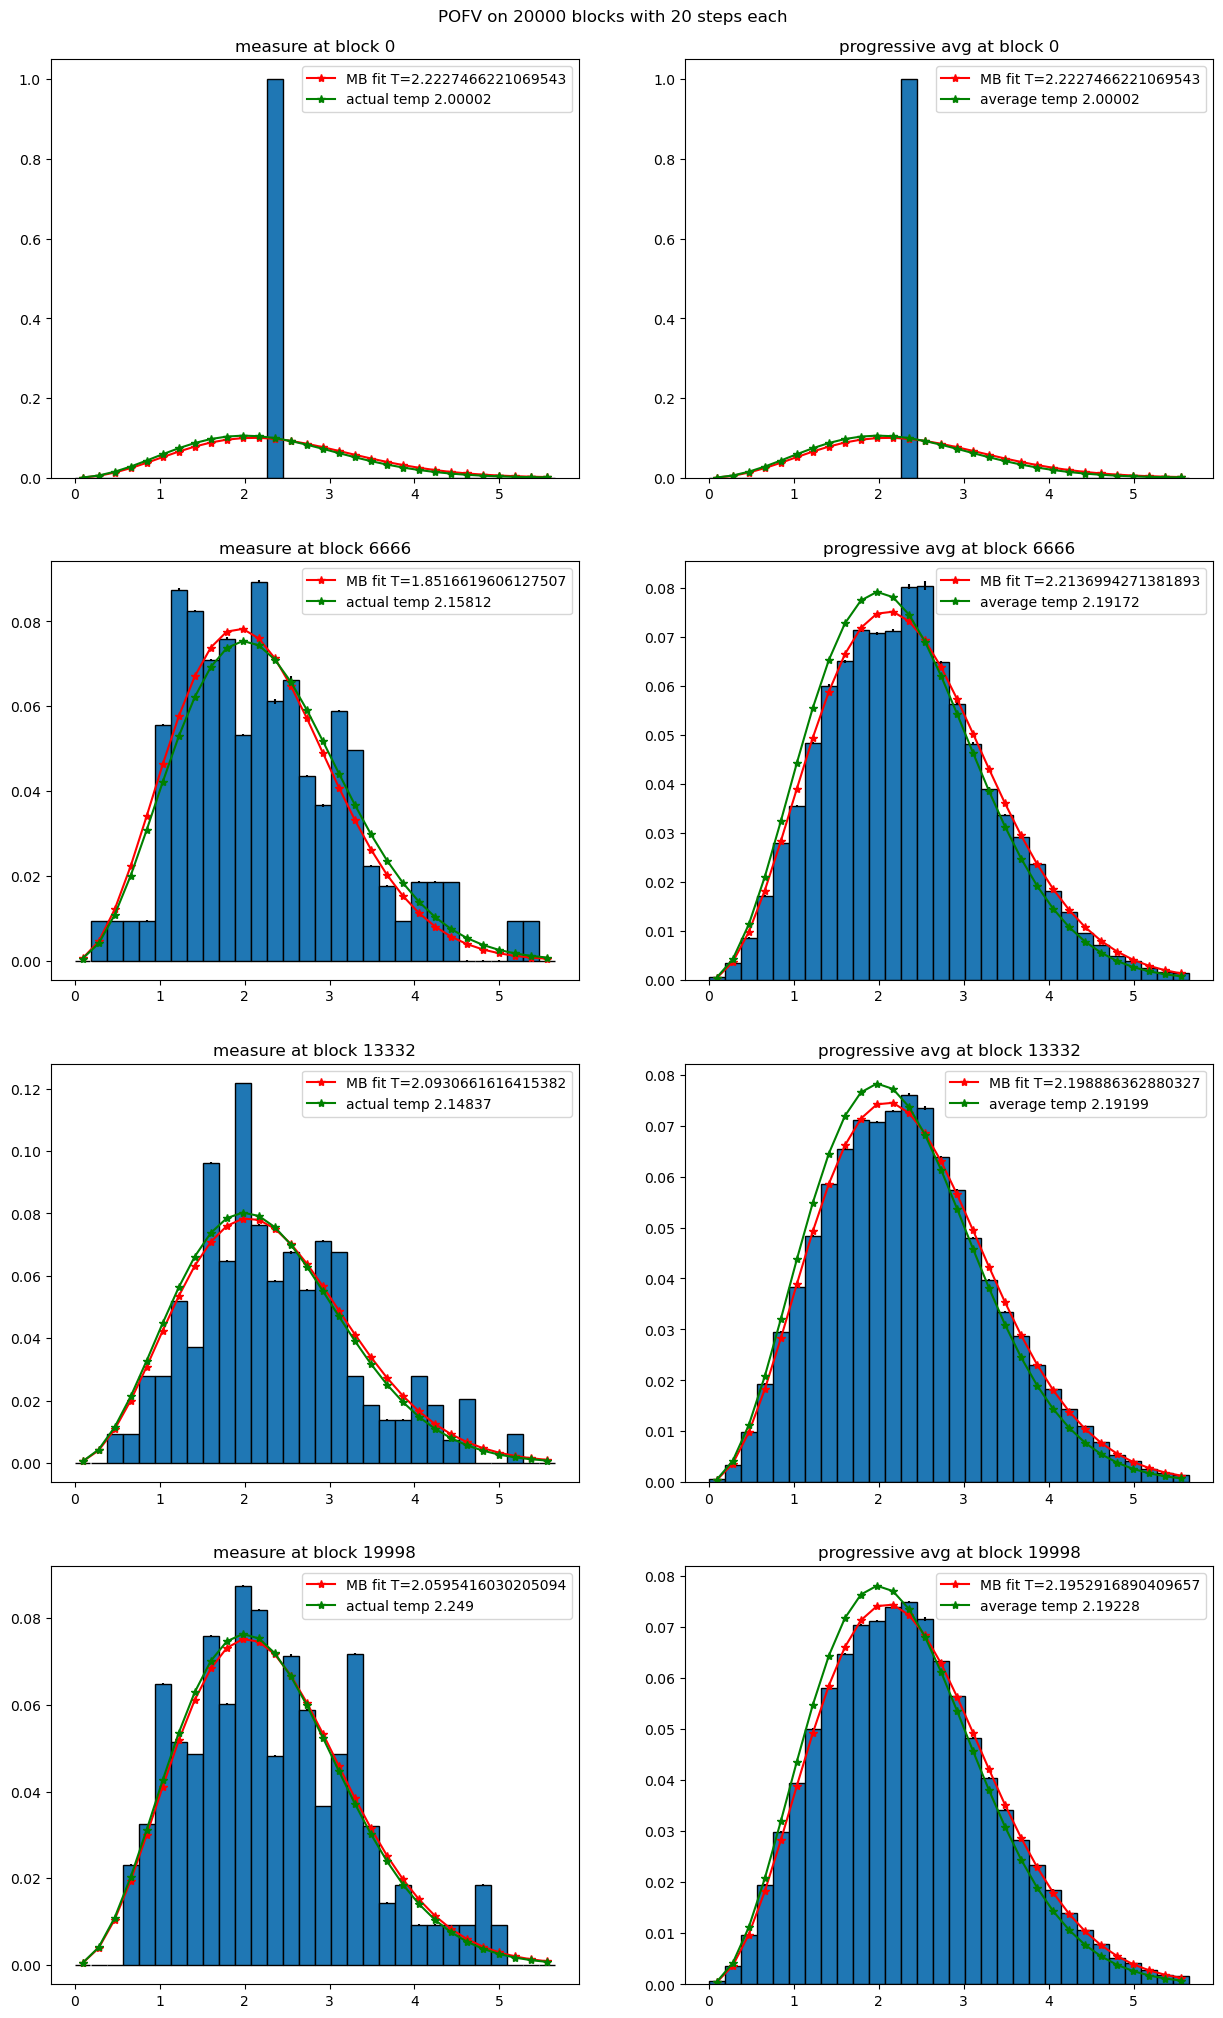

In [73]:
fig, ax=plt.subplots(nrows=4, ncols=2)
fig.set_figwidth(15)
fig.set_figheight(25)

fig.suptitle('POFV on 20000 blocks with 20 steps each', y=0.9)

step=df.block.max()//3
for k in range(4):
    #select k block pofv data 
    dfb=df.loc[df['block']==step*k].reset_index(drop=True)

    ax[k,  0].set_title(f'measure at block {step*k}')
    
    # actual data
    ax[k,  0].bar(
        dfb['#vel'], dfb['block_avg'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    
    # fit 
    ax[k, 0].plot(
        dfb['#vel'], MB(dfb['#vel'], delta_fit['T_block'][step*k] ,delta_fit['C_block'][step*k])
        , marker='*', c='r', label=f'MB fit T={delta_fit['T_block'][step*k]}')
    
    ax[k, 0].plot(
        dfb['#vel'], MB(dfb['#vel'], T_d['ACTUAL_T:'][k], delta_fit['C_block'][step*k])
        , marker='*', c='g', label=f'actual temp {T_d['ACTUAL_T:'][step*k]}')
    
    ax[k, 0].legend()#loc='lower center')

    # prog avg
    ax[k,  1].set_title(f'progressive avg at block {step*k}')
    # actual data
    ax[k,  1].bar(
        dfb['#vel'], dfb['prog_avg'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    # fit 
    ax[k, 1].plot(
        dfb['#vel'], MB(dfb['#vel'], delta_fit['T_ave'][step*k],delta_fit['C_ave'][step*k])
        , marker='*', c='r', label=f'MB fit T={delta_fit['T_ave'][step*k]}')
    ax[k, 1].plot(
        dfb['#vel'], MB(dfb['#vel'], T_d['T_AVE:'][k], delta_fit['C_ave'][step*k])
        , marker='*', c='g', label=f'average temp {T_d['T_AVE:'][step*k]}')
    
    ax[k, 1].legend()#loc='lower center')


plt.show()

With the evolution of the system return to a Maxwell-Boltzmann distribution.

In the following image are reported the values of temperature obtained by a Maxwell-Boltzmann fit on the velocity distribution compared with the measured values. Initially the values are significally different but as the distribution converge to MB they become more similar.

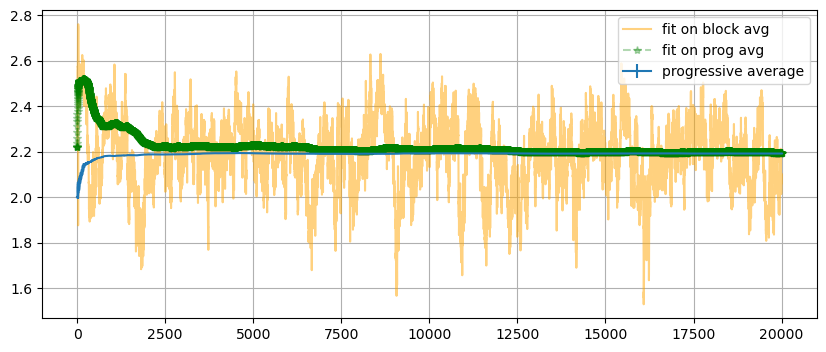

In [74]:
plt.figure(figsize=(10, 4))
plt.plot(delta_fit['T_block'],'-',color='orange', alpha=0.5,  label='fit on block avg')
plt.plot(delta_fit['T_ave'],'--*', color='g', alpha=0.3, label='fit on prog avg')
plt.errorbar(T_d['#BLOCK:'], T_d['T_AVE:'], yerr=T_d['ERROR:'],  label='progressive average')
plt.grid()
plt.legend()
plt.show()

### Properties

In [ ]:
K_d=pd.read_csv('OUTPUT/distrib/delta/kinetic_energy.dat', delimiter=r"\s+")
U_d=pd.read_csv('OUTPUT/distrib/delta/potential_energy.dat', delimiter=r"\s+")
P_d=pd.read_csv('OUTPUT/distrib/delta/pressure.dat', delimiter=r"\s+")

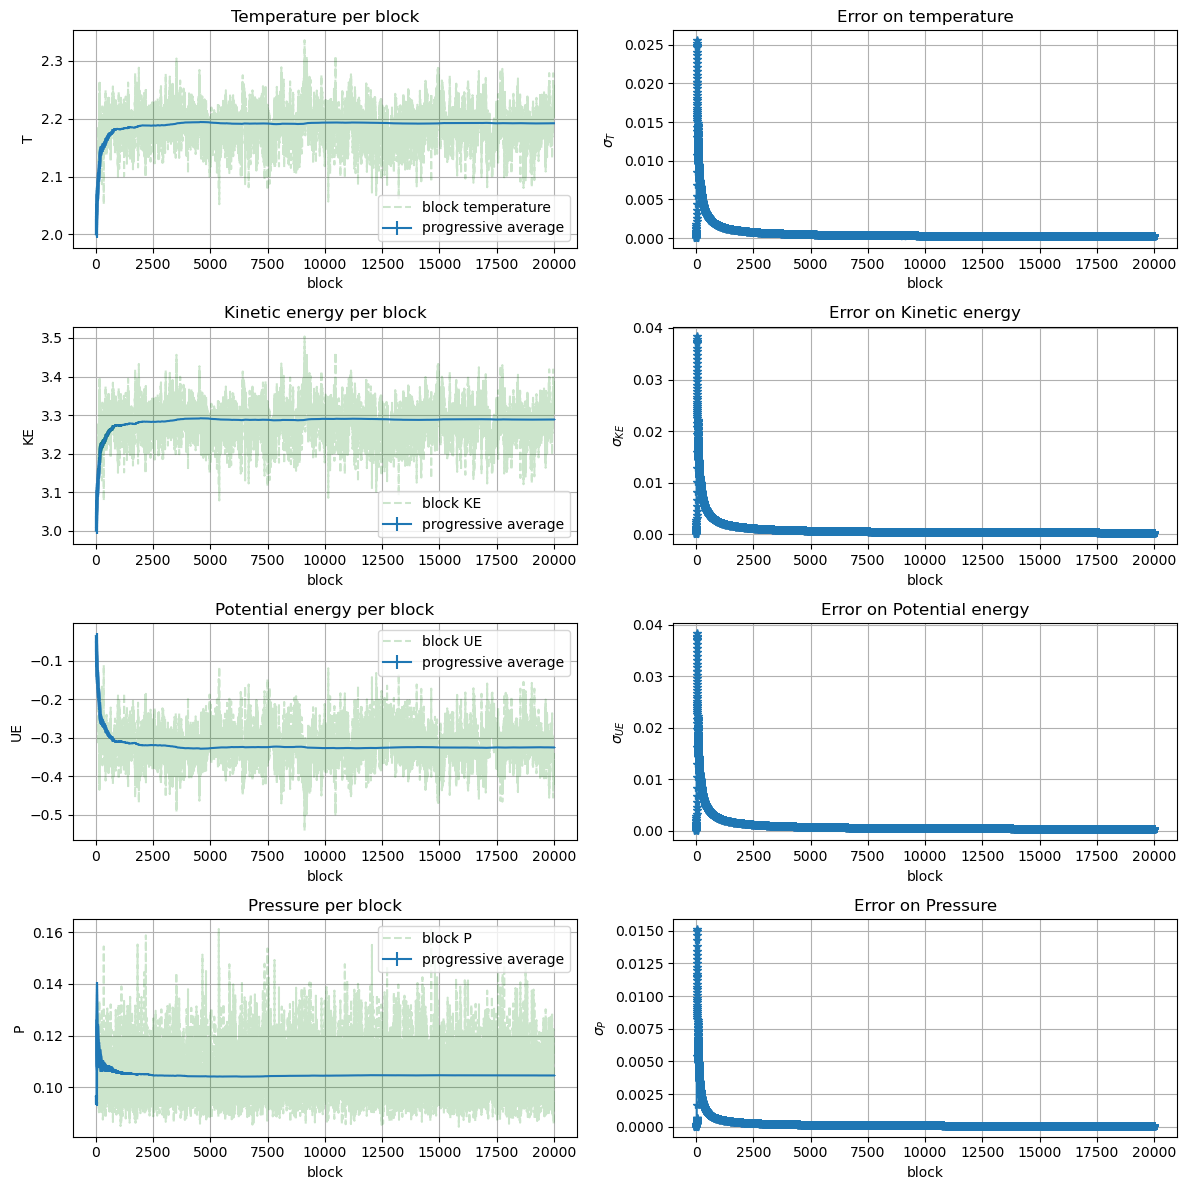

In [83]:
fig, ax = plt.subplots(4,2,  figsize=(12, 12))

ax[0, 0].set_title('Temperature per block')
# block averages
ax[0, 0].plot(
    T_d['#BLOCK:'][100:], T_d['ACTUAL_T:'][100:], #sliced for better visualization
    '--',color='g', alpha=0.2, label='block temperature'
) 

# progressive averages
ax[0, 0].errorbar(T_d['#BLOCK:'], T_d['T_AVE:'], yerr=T_d['ERROR:'],  label='progressive average')
ax[0, 0].set_ylabel('T')

ax[0,1].set_title('Error on temperature')
ax[0,1].plot(T_d['#BLOCK:'], T_d['ERROR:'], '-*')
ax[0,1].set_ylabel(r'$\sigma_T$')


ax[1,0].set_title('Kinetic energy per block')
# progressive averages
ax[1,0].errorbar(K_d['#BLOCK:'], K_d['KE_AVE:'], yerr=K_d['ERROR:'], label='progressive average')
# block averages
ax[1,0].plot(K_d['#BLOCK:'][100:], K_d['ACTUAL_KE:'][100:], '--',color='g', alpha=0.2, label='block KE')
ax[1,0].set_ylabel('KE')


ax[1,1].set_title('Error on Kinetic energy')
ax[1,1].plot(K_d['#BLOCK:'], K_d['ERROR:'], '-*')
ax[1,1].set_ylabel(r'$\sigma_{KE}$')


ax[2,0].set_title('Potential energy per block')
ax[2,0].plot(U_d['#BLOCK:'][100:], U_d['ACTUAL_PE:'][100:], ls='--', color='g', alpha=0.2, label='block UE')
ax[2,0].errorbar(U_d['#BLOCK:'], U_d['PE_AVE:'], yerr=U_d['ERROR:'], label='progressive average')
ax[2,0].set_ylabel('UE')

ax[2,1].set_title('Error on Potential energy')
ax[2,1].plot(U_d['#BLOCK:'], U_d['ERROR:'], '-*')
ax[2,1].set_ylabel(r'$\sigma_{UE}$')


ax[3,0].set_title('Pressure per block')
ax[3,0].plot(P_d['#BLOCK:'][100:], P_d['ACTUAL_P:'][100:], ls='--', color='g', alpha=0.2,label='block P')
ax[3,0].errorbar(P_d['#BLOCK:'], P_d['P_AVE:'], yerr=P_d['ERROR:'], label='progressive average')
ax[3,0].set_ylabel('P')

ax[3,1].set_title('Error on Pressure')
ax[3,1].plot(P_d['#BLOCK:'], P_d['ERROR:'], '-*')
ax[3,1].set_ylabel(r'$\sigma_{P}$')

for k in range(4):
    for j in range(2):
        ax[k,j].grid()
        ax[k, j].set_xlabel('block')
    ax[k, 0].legend()

fig.tight_layout()

plt.show()

### Histograms Heatmap 
The image below show the convergence of the distribution from a delta to a MB along the blocks of the MD process.  

In [9]:
histos=pd.DataFrame(columns=['vel']+[f'block_{k}' for k in range(400)])
histos['vel']=df.loc[df['block']==0]['#vel'].values
for k in range(400):
    histos[f'block_{k}']=df.loc[df.block==k]['block_avg'].values 
    


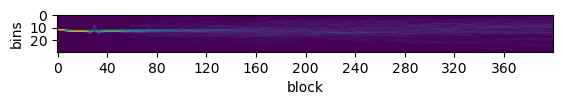

In [325]:
fig,ax = plt.subplots()
fig.set_figheight(10)
ax.imshow(histos[[f'block_{k}' for k in range(400)]])
plt.xlabel('block')#, size=150)
plt.ylabel('bins')#, size=150)
plt.xticks(range(0,  400, 40))#, size=100)
plt.yticks(range(0,  30, 10))#, size=100)

plt.savefig('images/delta_hist.png')

plt.show()

## Exercise 04.3 [back to the future]

I runned the simulation backwards starting from the last configuration of a MD simulation with a delta initial distribution of velocities. I used one throw per block to visualize the delta distribution.

The final block of the backward simulation returned to a delta distribution of velocities.


The delta-starting simulation was computed with the following parameters"

- TEMPERATURE= 2
- NPART= 108
- SIDE=      12.9266     12.9266     12.9266
- R_CUT= 5
- DELTA= 0.001
- NBLOCKS= 2000
- NSTEPS= 1
- INITIAL DISTRIBUTION TYPE= Delta

In [2]:
# POFV data
df_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/pofv.dat', header=None, names=['#vel', 'block_avg', 'prog_av', 'err'], skiprows=1,
               sep=r"\s+")
df_btf['block']=0
df_btf['block']=df_btf.index//30

# Temperature data
T_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/temperature.dat', skiprows=1, delimiter=r'\s+',names=['block','actual_T','T_ave','error'])



/tmp/ipykernel_4889/2678452637.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[k//2,  k%2].legend(loc='lower center')


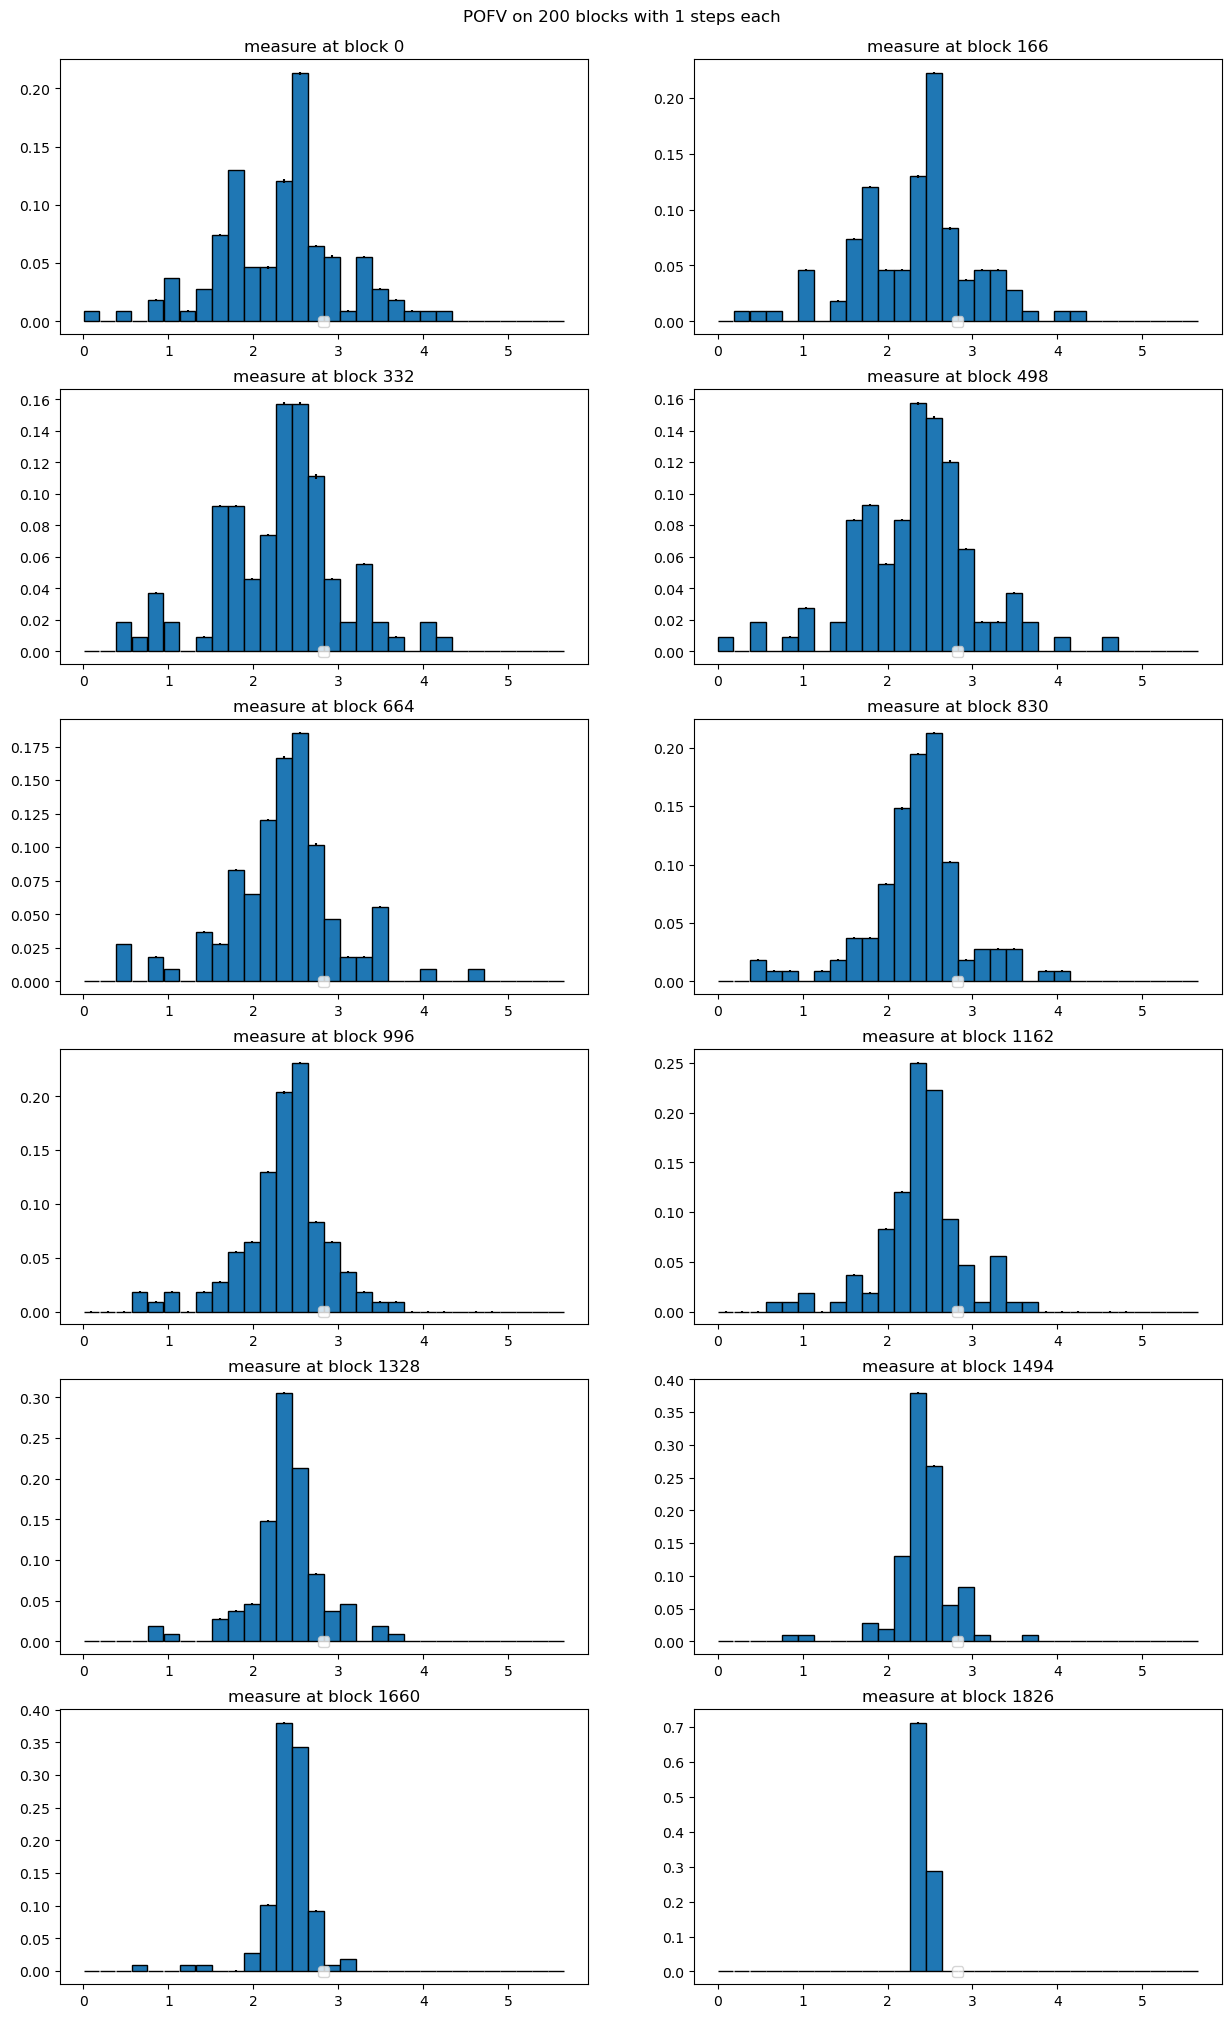

In [3]:
fig, ax=plt.subplots(nrows=6, ncols=2)
fig.set_figwidth(15)
fig.set_figheight(25)

fig.suptitle('POFV on 200 blocks with 1 steps each', y=0.9)

step=df_btf.block.max()//12
for k in range(12):
    #select k block pofv data 
    dfb=df_btf.loc[df_btf['block']==step*(k+1)].reset_index(drop=True)

    ax[k//2,  k%2].set_title(f'measure at block {step*k}')
    
    # actual data
    ax[k//2,  k%2].bar(
        dfb['#vel'], dfb['block_avg'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    
    ax[k//2,  k%2].legend(loc='lower center')

plt.show()

Below a picture of the last block of the simulation

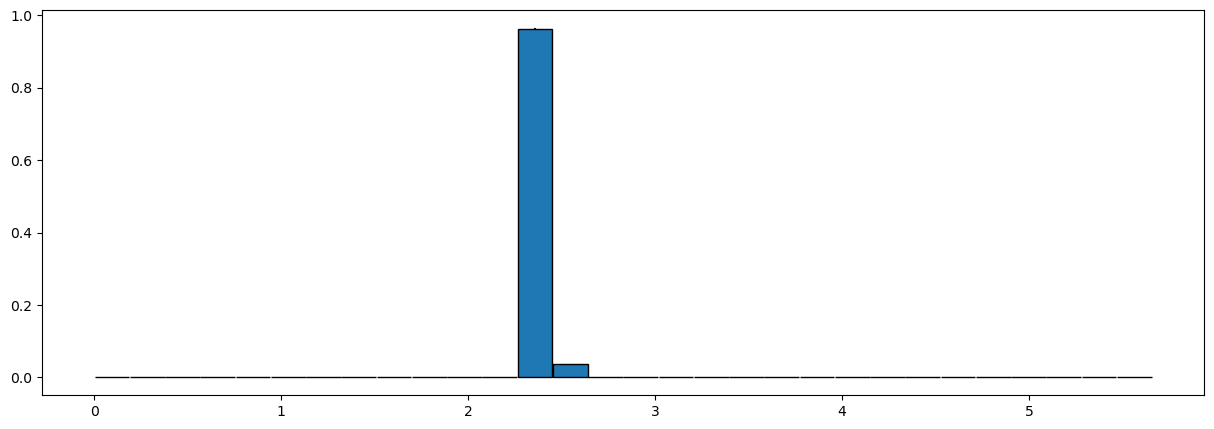

In [5]:
last=df_btf.loc[df_btf['block']==df_btf['block'].max()].reset_index(drop=True)
plt.figure(figsize=(15, 5))
plt.bar(
        last['#vel'], last['block_avg'], 
        yerr=last['err'], 
        width=last['#vel'].max()/30, edgecolor='black')

plt.show()

### Properties

The properties measured in the evolution backwards and afterwards are simmetric. So the MD evolution has been succesfully reversed

In [6]:
K_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/kinetic_energy.dat', delimiter=r"\s+")
U_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/potential_energy.dat', delimiter=r"\s+")
P_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/pressure.dat', delimiter=r"\s+")

In [10]:
T_atf=pd.read_csv('OUTPUT/bckwd/200bl/fw/temperature.dat', skiprows=1, delimiter=r'\s+',names=['block','actual_T','T_ave','error'])
K_atf=pd.read_csv('OUTPUT/bckwd/200bl/fw/kinetic_energy.dat', delimiter=r"\s+")
U_atf=pd.read_csv('OUTPUT/bckwd/200bl/fw/potential_energy.dat', delimiter=r"\s+")
P_atf=pd.read_csv('OUTPUT/bckwd/200bl/fw/pressure.dat', delimiter=r"\s+")

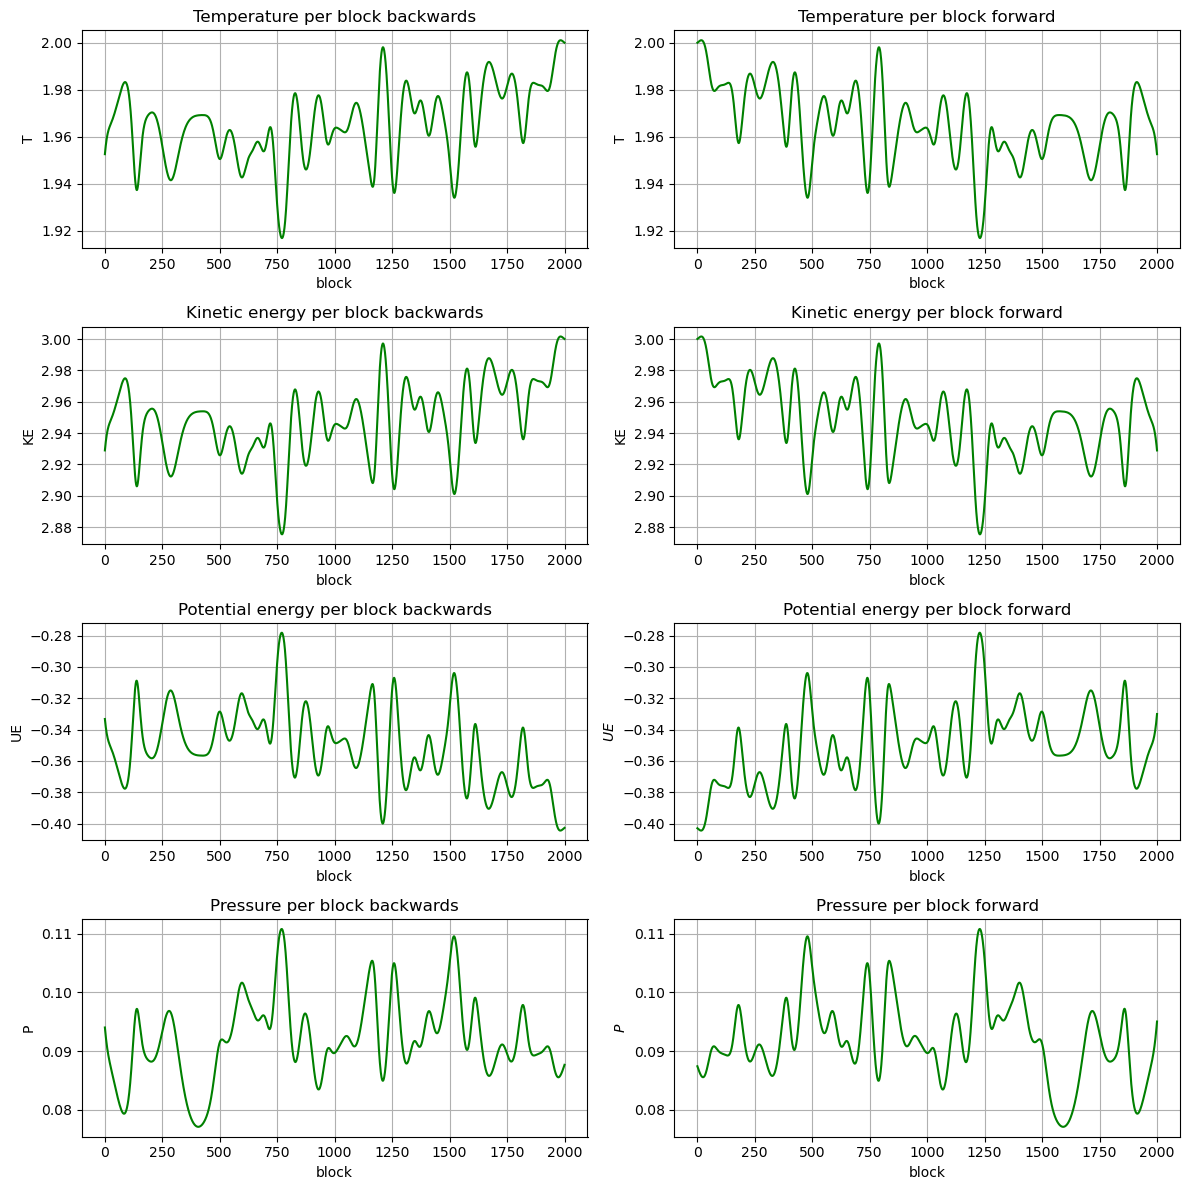

In [19]:
fig, ax = plt.subplots(4,2,  figsize=(12, 12))
ax[0, 0].set_title('Temperature per block backwards')

# block averages
ax[0, 0].plot(T_btf['block'], T_btf['actual_T'], '-',color='g', label='block temperature') #sliced for better visualization
ax[0, 0].set_ylabel('T')

ax[0, 1].set_title('Temperature per block forward')
ax[0, 1].plot(T_atf['block'], T_atf['actual_T'], '-',color='g', alpha=1, label='block temperature') #sliced for better visualization
ax[0, 1].set_ylabel('T')


ax[1,0].set_title('Kinetic energy per block backwards')
ax[1,0].plot(K_btf['#BLOCK:'], K_btf['ACTUAL_KE:'], '-',color='g', alpha=1, label='block KE')
ax[1,0].set_ylabel('KE')


ax[1,1].set_title('Kinetic energy per block forward')
ax[1,1].plot(K_atf['#BLOCK:'], K_atf['ACTUAL_KE:'], '-',color='g', alpha=1, label='block KE')
ax[1,1].set_ylabel('KE')


ax[2,0].set_title('Potential energy per block backwards')
ax[2,0].plot(U_btf['#BLOCK:'], U_btf['ACTUAL_PE:'], '-', color='g', alpha=1, label='block UE')
ax[2,0].set_ylabel('UE')

ax[2,1].set_title('Potential energy per block forward')
ax[2,1].plot(U_atf['#BLOCK:'], U_atf['ACTUAL_PE:'], '-', color='g', alpha=1, label='block UE')
ax[2,1].set_ylabel(r'${UE}$')


ax[3,0].set_title('Pressure per block backwards')
ax[3,0].plot(P_btf['#BLOCK:'], P_btf['ACTUAL_P:'], '-', color='g', alpha=1,label='block P')
ax[3,0].set_ylabel('P')

ax[3,1].set_title('Pressure per block forward')
ax[3,1].plot(P_atf['#BLOCK:'], P_atf['ACTUAL_P:'], '-', color='g', alpha=1,label='block P')
ax[3,1].set_ylabel(r'${P}$')

for k in range(4):
    for j in range(2):
        ax[k,j].grid()
        ax[k, j].set_xlabel('block')

fig.tight_layout()

plt.show()